In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from Training_model import train_model
from Data_generation import make_loader
from OneHot_model import OneHotDecoder
from Model_analysis import (
    statistical_complexity,
    statistical_complexity_empirical,
    statistical_complexity_compare,
    FW_BW_attention_comparison,
    FW_BW_loss_comparison,
    compare_FW_BW_latents,
    plot_attention_heatmap,
    plot_perplexity,
    compare_FW_BW_latents, latent_extraction
)

In [ ]:
num_token = 3
d_model = 20
max_len = 1000
batch_size = 32
num_samples = 5000
max_epochs = 50
lr = 1e-2
p, q = 0.3, 0.4

    #generate data
from Data_generation import coin_generation, Rev_HMM_generation
data, states = coin_generation(num_samples=num_samples, seq_len=max_len, p=p, q=q)
data_rev, states_rev = Rev_HMM_generation(data, states)
# Data Loader
train_loader = make_loader(data, states, batch_size=batch_size, mode="forward")
train_loader_rev = make_loader(data_rev, states_rev, batch_size=batch_size, mode="backward")

In [ ]:
from Training_model import test_train_validation, _eval_loss_on_loader
train_loader, test_loader = test_train_validation(train_loader, 
                                                              test_ratio=0.2, 
                                                              train_ratio=0.7)
train_inoput, train_target = next(iter(train_loader))
print("sample length: ", len(train_loader.dataset)) 
print("Train Input shape:", train_inoput.shape)   # Expected: (batch_size, seq_len)
print("Train Target shape:", train_target.shape) # Expected: (batch_size, seq_len)


test_input, test_target = next(iter(test_loader))
print("sample length: ", len(test_loader.dataset))
print("Test Input shape:", test_input.shape)   # Expected: (batch_size, seq_len)
print("Test Target shape:", test_target.shape) # Expected: (batch_size, seq_len)

In [ ]:
from Training_model import train_test_val_pipeline

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from Training_model import train_model, train_test_val_pipeline
from Data_generation import make_loader
from OneHot_model import OneHotDecoder
from Model_analysis import (
    statistical_complexity,
    statistical_complexity_empirical,
    statistical_complexity_compare,
    FW_BW_attention_comparison,
    FW_BW_loss_comparison,
    compare_FW_BW_latents,
    plot_attention_heatmap,
    plot_perplexity,
    compare_FW_BW_latents, latent_extraction
)

num_token = 3
d_model = 20
max_len = 1000
batch_size = 32
num_samples = 500
max_epochs = 50
lr = 1e-2
p, q = 0.3, 0.4

    #generate data
from Data_generation import coin_generation, Rev_HMM_generation, flower_process_generation
data, states = coin_generation(num_samples=num_samples, seq_len=max_len, p=p, q=q)
data_rev, states_rev = Rev_HMM_generation(data, states)
#data_flower, states_flower = flower_process_generation(num_samples=num_samples, seq_len=max_len, n=4, m=2)
# Data Loader
train_loader = make_loader(data, states, batch_size=batch_size, mode="forward")
train_loader_rev = make_loader(data_rev, states_rev, batch_size=batch_size, mode="backward")

/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
results = train_test_val_pipeline(train_loader, test_ratio=(0.2, 0.8), n_folds=5, embed_type="onehot", num_token=num_token)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 |

Initial split ratios: test=0.2, train_val=0.8
Total samples: 500
Splitting into: 400 train, 100 test samples
Actual split sizes: Train=400, Test=100

  5-Fold Cross-Validation Pipeline
  Total samples    : 500
  Held-out test    : 100  (20%)
  Train+Val pool   : 400
  Folds            : 5
  Mode             : forward  |  embed: onehot
  d_model=20  max_epochs=5  lr=0.01


--- Fold 1/5 ---
  Train samples: 320  |  Val samples: 80


/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Epoch 4: 100%|██████████| 10/10 [00:01<00:00,  7.28it/s, v_num=2531, train_loss_step=0.918, train_perplexity_step=2.500, train_loss_epoch=0.922, train_perplexity_epoch=2.510]

`Trainer.fit` stopped: `max_epochs=5` reached.


...

Epoch 4: 100%|██████████| 10/10 [00:01<00:00,  7.63it/s, v_num=2534, train_loss_step=0.926, train_perplexity_step=2.520, train_loss_epoch=0.922, train_perplexity_epoch=2.520]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 60     | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 63     | train | 0    
  | other params | n/a                | 60     | n/a   | n/a  
--------------------------------------------------------------------
9.5 K     

  ✓ Fold 4  val loss: 0.9210  |  val ppl: 2.5117

--- Fold 5/5 ---
  Train samples: 320  |  Val samples: 80
Epoch 4: 100%|██████████| 10/10 [00:01<00:00,  7.79it/s, v_num=2535, train_loss_step=0.925, train_perplexity_step=2.520, train_loss_epoch=0.924, train_perplexity_epoch=2.520]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 10/10 [00:01<00:00,  7.63it/s, v_num=2535, train_loss_step=0.925, train_perplexity_step=2.520, train_loss_epoch=0.924, train_perplexity_epoch=2.520]
  ✓ Fold 5  val loss: 0.9263  |  val ppl: 2.5252

  Best fold: 1  (val loss=0.9200, val ppl=2.5094)

  Evaluating ALL fold models on the held-out test set …
    Fold 1: test loss=0.9245  test ppl=2.5206  ★ best
    Fold 2: test loss=0.9260  test ppl=2.5243
    Fold 3: test loss=0.9252  test ppl=2.5225
    Fold 4: test loss=0.9247  test ppl=2.5210
    Fold 5: test loss=0.9289  test ppl=2.5318

  ✓ CV visualisation saved → cv_results.png

  HELD-OUT TEST SET  (best fold = 1)
  Test loss (best fold) : 0.9245 bits
  Test ppl  (best fold) : 2.5206

  Cross-Validation Summary
  Fold       Val Loss    Val PPL   Test PPL
  --------------------------------------------
  Fold 1       0.9200     2.5094     2.5206  ★
  Fold 2       0.9229     2.5166     2.5243
  Fold 3       0.9225     2.5157     2.5225
  Fold 4       0.9210 

In [3]:
model = results["best_model"]
final_latent = latent_extraction(model, train_loader)

In [4]:
# ── Switch to interactive backend BEFORE importing main or matplotlib ─────
# This must be the very first matplotlib call in the session.
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Jupyter inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 — registers 3D projection

import numpy as np
import pickle, os, sys
import torch
import umap
from sklearn.cluster import KMeans

# ── Add project root to path if needed ───────────────────────────────────
# sys.path.insert(0, '/path/to/your/project')  # uncomment if needed

from Data_generation import CoinDataset, Rev_HMM_generation, coin_generation
from OneHot_model import OneHotDecoder
from torch.utils.data import DataLoader
import torch.utils.data as tud

print('Imports OK')

class ChunkedDataset(tud.Dataset):

    def __init__(self, base: tud.Dataset, chunk_len: int, seed: int = 0):
        self.base  = base
        self.chunk = chunk_len
        self.rng   = np.random.default_rng(seed)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        inp, tgt = self.base[idx]          # shape (T,) each
        T = inp.shape[0]
        if T <= self.chunk:
            return inp, tgt
        start = int(self.rng.integers(0, T - self.chunk + 1))
        return inp[start: start + self.chunk], tgt[start: start + self.chunk]

class _SafeUnpickler(pickle.Unpickler):
    _REMAP = {
        ('__main__', 'ChunkedDataset'): ChunkedDataset,
        ('main',     'ChunkedDataset'): ChunkedDataset,
    }
    def find_class(self, module, name):
        return self._REMAP.get((module, name)) or super().find_class(module, name)

def safe_load_pkl(path):
    with open(path, 'rb') as f:
        return _SafeUnpickler(f).load()
    
# ── Core draw_umap function ───────────────────────────────────────────────
def draw_umap(data, color=None, n_neighbors=100, min_dist=0.1,
              n_components=2, metric='euclidean', title='', cmap='plasma',
              save_path=None, figsize=(8, 6)):
    """
    Parameters
    ----------
    data        : np.ndarray (N, D)
    color       : array-like (N,) or None  →  None = timestep index (gradient)
                  pass integer token ids for discrete colouring
    n_neighbors : 100 recommended for 1000 points
    n_components: 2 or 3
    cmap        : 'plasma' for continuous, 'tab10' for discrete tokens
    save_path   : optional path to save PNG

    Returns
    -------
    u : np.ndarray (N, n_components) — the embedding coordinates
    """
    if color is None:
        color = np.arange(len(data))   # timestep gradient

    fit = umap.UMAP(
        n_neighbors=min(n_neighbors, len(data) - 1),
        min_dist=min_dist,
        n_components=n_components,
        metric=metric,
        random_state=42,
    )
    u = fit.fit_transform(data)

    fig = plt.figure(figsize=figsize)
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(u[:, 0], u[:, 1], u[:, 2],
                        c=color, s=10, cmap=cmap, alpha=0.7)
    else:
        ax = fig.add_subplot(111)
        sc = ax.scatter(u[:, 0], u[:, 1],
                        c=color, s=10, cmap=cmap, alpha=0.7)

    plt.colorbar(sc, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        print(f'  saved → {save_path}')

    plt.show()
    return u


def draw_umap_tokens(data, token_ids, num_token, n_neighbors=100,
                     min_dist=0.1, title='', save_path=None, figsize=(8, 6)):
    """
    2-D UMAP with one scatter series per token — uses tab10, shows legend.
    token_ids : integer array (N,) with values in [0, num_token)
    """
    fit = umap.UMAP(
        n_neighbors=min(n_neighbors, len(data) - 1),
        min_dist=min_dist,
        n_components=2,
        metric='euclidean',
        random_state=42,
    )
    u = fit.fit_transform(data)

    cmap = plt.cm.tab10
    fig, ax = plt.subplots(figsize=figsize)
    for tok in range(num_token):
        mask = token_ids == tok
        if not mask.any(): continue
        ax.scatter(u[mask, 0], u[mask, 1],
                   c=[cmap(tok / max(num_token - 1, 1))],
                   label=f'Token {tok}', s=10, alpha=0.7)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(markerscale=3, fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        print(f'  saved → {save_path}')

    plt.show()
    return u


def draw_umap_states(data, n_states, n_neighbors=100, min_dist=0.1,
                     token_ids=None, title='', save_path=None, figsize=(8, 6)):
    """
    2-D UMAP coloured by k-means causal states.
    If token_ids is also provided, annotates each state cluster with which
    tokens it contains — revealing e.g. that tokens 0 and 2 share state S0.
    """
    fit = umap.UMAP(
        n_neighbors=min(n_neighbors, len(data) - 1),
        min_dist=min_dist,
        n_components=2,
        metric='euclidean',
        random_state=42,
    )
    u = fit.fit_transform(data)

    km = KMeans(n_clusters=n_states, random_state=42, n_init=10)
    labels = km.fit_predict(data)

    cmap = plt.cm.Set1
    fig, ax = plt.subplots(figsize=figsize)
    for s in range(n_states):
        mask = labels == s
        if not mask.any(): continue
        if token_ids is not None:
            toks = np.unique(token_ids[mask]).tolist()
            lbl  = f'State {s}  (tokens {toks})'
        else:
            lbl  = f'State {s}'
        ax.scatter(u[mask, 0], u[mask, 1],
                   c=[cmap(s / max(n_states - 1, 1))],
                   label=lbl, s=10, alpha=0.7)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(markerscale=3, fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        print(f'  saved → {save_path}')

    plt.show()
    return u, labels


print('draw_umap functions defined')

Imports OK
draw_umap functions defined


In [5]:
latent, input_latent, target_latent = final_latent

n = 1000

flat_latents_fw = latent.reshape(-1, latent.shape[-1])
reduced = flat_latents_fw[:n]
draw_umap(reduced, color=None, n_neighbors=100, min_dist=0.1, n_components=3, metric='euclidean', title='Forward Latents')


/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 800x600 with 2 Axes>

array([[12.444954 , -1.3913981, 13.739475 ],
       [-4.133323 ,  1.823342 ,  5.1098685],
       [-4.061048 ,  1.881081 ,  5.122002 ],
       ...,
       [11.629311 ,  0.1613806, 13.009675 ],
       [-2.607854 ,  1.9793577,  2.1968906],
       [12.499993 , -1.4188635, 13.75193  ]],
      shape=(1000, 3), dtype=float32)

In [6]:
# ── 1. 3-D UMAP — timestep gradient (plasma) ─────────────────────────────
u_fw_3d = draw_umap(
    reduced, color=None,        # None = timestep index
    n_neighbors=100, min_dist=0.1, n_components=3,
    title=f'— Forward Latents 3D (timestep)',
    cmap='plasma',
)

/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 800x600 with 2 Axes>

In [ ]:
latent

In [ ]:
num_token = 6
train_loader = make_loader(data_flower, states_flower, batch_size=batch_size, mode="forward")
data_rev, states_rev = Rev_HMM_generation(data_flower, states_flower)
train_loader_rev = make_loader(data_rev, states_rev, batch_size=batch_size, mode="backward")
all_data = train_test_val_pipeline(train_loader_rev, test_ratio=(0.2, 0.8), n_folds=5, embed_type="onehot", num_token=num_token)

# Check New code

In [ ]:
import umap
def draw_umap(data, color=None, n_neighbors=300, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()

In [ ]:
num_token = 3
d_model = 20
max_len = 500
batch_size = 32
num_samples = batch_size*10
max_epochs = 20
lr = 1e-2
p, q = 0.4, 0.8

train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "forward")
train_loader_bw = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "backward")


records_fw = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_bw = train_model(train_loader_bw, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")

In [ ]:
n = 1000
latents_fw,_,_ = latent_extraction(records_fw.model, train_loader)
latents_bw,_,_ = latent_extraction(records_bw.model, train_loader)

flat_latents_fw = latents_fw.reshape(-1, latents_fw.shape[-1])
reduced = flat_latents_fw[:n]
draw_umap(reduced, color=None, n_neighbors=100, min_dist=0.1, n_components=3, metric='euclidean', title='Forward Latents')

flat_latents_bw = latents_bw.reshape(-1, latents_bw.shape[-1])
reduced = flat_latents_bw[:n]
draw_umap(reduced, color=None, n_neighbors=100, min_dist=0.1, n_components=3, metric='euclidean', title='Backward Latents')

In [ ]:
statistical_complexity(p, q, mode = "forward")

In [ ]:
statistical_complexity_empirical(records_fw.model, train_loader_bw, use_t="first", k=2)

In [ ]:
# Print what the backward loader actually gives
for batch in train_loader:
    inputs, targets = batch  # BEFORE any swap
    print("Batch[0] input:", inputs[0, :10])
    print("Batch[0] target:", targets[0, :10])
    break

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(records_fw.step_loss, label='Forward Loss')
plt.plot(records_bw.step_loss, label='Backward Loss')
plt.legend()
plt.grid()
plt.title('Training Loss Comparison', fontsize=18)
plt.xlabel('Training Steps')
plt.ylabel('Loss')

plt.figure(figsize=(12,4))
plt.plot(np.array(records_bw.step_loss) - np.array(records_fw.step_loss), label='Loss difference (BW - FW)', color = 'red')
plt.legend()
plt.grid()
plt.title('Loss Difference (BW - FW)', fontsize=18)
plt.xlabel('Training Steps')
plt.ylabel('Loss Difference')

In [ ]:
records_fw.epoch_loss[-1], records_bw.epoch_loss[-1], records_bw.epoch_loss[-1] - records_fw.epoch_loss[-1]

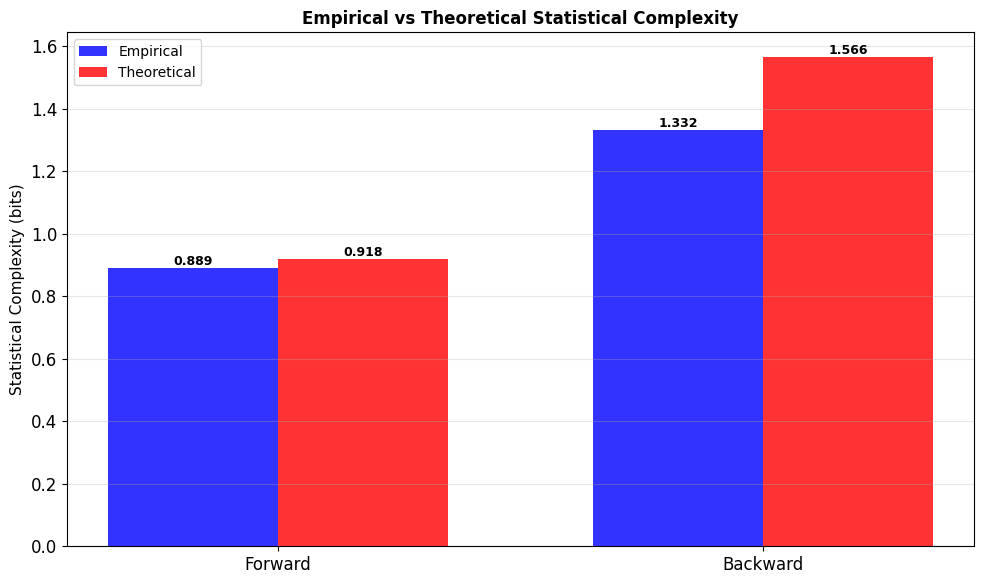

In [ ]:
from Data_generation import HMM_generation
HMM_generation(num_samples = 5, seq_len = 5, p = 0.4, q = 0.8)

In [ ]:
from Data_generation import Rev_HMM_generation
Rev_HMM_generation(num_samples = 5, seq_len = 5, p = 0.4, q = 0.8)

# Testing Reverse input in forward model:

- compare:
Reverse input in forward model = forward input in backward model

(sanity check)

In [ ]:
num_token = 3
d_model = 20
max_len = 800
batch_size = 32
num_samples = batch_size*10
max_epochs = 50
lr = 1e-2
p, q = 0.4, 0.8

rev_train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "backward")
train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "forward")


records_fw_data_fw_model = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_rev_data_fw_model = train_model(rev_train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_fw_data_rev_model = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'backward', embed_type="onehot")
records_rev_data_rev_model = train_model(rev_train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'backward', embed_type="onehot")
# records_fw_data_fw_model = records_rev_data_rev_model
# records_rev_data_fw_model = records_rev_data_rev_model

Prelim

In [ ]:
input, target = next(iter(train_loader))

In [ ]:
input, target

In [ ]:
model_fw_data_fw_model = records_fw_data_fw_model.model
model_bw_data_fw_model = records_rev_data_fw_model.model
model_fw_data_bw_model = records_fw_data_rev_model.model
model_bw_data_bw_model = records_rev_data_rev_model.model

latents_fw_data_fw_model, input_fw_data_fw_model, _ = latent_extraction(model_fw_data_fw_model, train_loader)
latents_bw_data_fw_model, input_bw_data_fw_model, _ = latent_extraction(model_bw_data_fw_model, rev_train_loader)
latents_fw_data_bw_model, input_fw_data_bw_model, _ = latent_extraction(model_fw_data_bw_model, train_loader)
latents_bw_data_bw_model, input_bw_data_bw_model, _ = latent_extraction(model_bw_data_bw_model, rev_train_loader)

In [ ]:
latents_fw_data_bw_model

In [ ]:
n = 1000

flat_latents_fw_data_fw_model = latents_fw_data_fw_model.reshape(-1, latents_fw_data_fw_model.shape[-1])
reduced_fw_data_fw_model = flat_latents_fw_data_fw_model[:n]
reduced_int_fw_data_fw_model = input_fw_data_fw_model.reshape(-1)[:n]

flat_latents_bw_data_fw_model = latents_bw_data_fw_model.reshape(-1, latents_bw_data_fw_model.shape[-1])
reduced_bw_data_fw_model = flat_latents_bw_data_fw_model[:n]
reduced_int_bw_data_fw_model = input_bw_data_fw_model.reshape(-1)[:n]


flat_latents_fw_data_bw_model = latents_fw_data_bw_model.reshape(-1, latents_fw_data_bw_model.shape[-1])
reduced_fw_data_bw_model = flat_latents_fw_data_bw_model[:n]
reduced_int_fw_data_bw_model = input_fw_data_bw_model.reshape(-1)[:n]

flat_latents_bw_data_bw_model = latents_bw_data_bw_model.reshape(-1, latents_bw_data_bw_model.shape[-1])
reduced_bw_data_bw_model = flat_latents_bw_data_bw_model[:n]
reduced_int_bw_data_bw_model = input_bw_data_bw_model.reshape(-1)[:n]

In [ ]:
reduced_fw_data_bw_model

In [ ]:
import umap
def draw_umap(data, color=None, n_neighbors=300, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()

In [ ]:
n_neighbors=100
min_dist=0.1
n_components=2
metric='euclidean'
token_colors = {0: 'red', 1: 'green', 2: 'purple'}



fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
u = fit.fit_transform(reduced_fw_data_fw_model)
for token in [0, 1, 2]:
    mask = reduced_int_fw_data_fw_model[:n] == token
    ax[0, 0].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
ax[0, 0].set_title('fw_data_fw_model', fontsize=14)
ax[0, 0].legend()

fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
u = fit.fit_transform(reduced_fw_data_bw_model)
for token in [0, 1, 2]:
    mask = reduced_int_fw_data_bw_model[:n] == token
    ax[0, 1].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
ax[0, 1].set_title('fw_data_bw_model', fontsize=14)
ax[0, 1].legend()

fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
u = fit.fit_transform(reduced_bw_data_fw_model)
for token in [0, 1, 2]:
    mask = reduced_int_bw_data_fw_model[:n] == token
    ax[1, 0].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
ax[1, 0].set_title('bw_data_fw_model', fontsize=14)
ax[1, 0].legend()

fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
u = fit.fit_transform(reduced_bw_data_bw_model)
for token in [0, 1, 2]:
    mask = reduced_int_bw_data_bw_model[:n] == token
    ax[1, 1].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}' )
ax[1, 1].set_title('bw_data_bw_model', fontsize=14)
ax[1, 1].legend()
plt.tight_layout()
plt.show()

In [ ]:
draw_umap(reduced_fw_data_fw_model, n_neighbors=200, n_components=3, color=None, title='FW data - FW model')
draw_umap(reduced_fw_data_bw_model, n_neighbors=200,n_components=3, color=None, title='FW data - BW model')

print("bw_data:")
draw_umap(reduced_bw_data_fw_model, n_neighbors=200,n_components=3, color=None, title='BW data - FW model')
draw_umap(reduced_bw_data_bw_model, n_neighbors=200,n_components=3, color=None, title='BW data - BW model')

loss function

In [ ]:
FW_BW_loss_comparison(records_fw_data_fw_model, records_fw_data_rev_model)
FW_BW_loss_comparison(records_rev_data_fw_model, records_rev_data_rev_model)

# General Testing: word embedding vs one hot

In [ ]:
max_len = 800
batch_size = 32
max_epochs = 300
num_token = 3
d_model = 20
p, q = 0.4, 0.8

In [ ]:

def all_tests(embed_type = "onehot", max_epochs = 100, lr = 1e-2, 
              max_len = 800, batch_size = 32, num_samples = batch_size*10):
    
    rev_train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "backward")
    train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "forward")
    
    print(f"Training models: {embed_type}")
    records_fw_data_fw_model = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type=embed_type)
    records_rev_data_fw_model = train_model(rev_train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type=embed_type)
    records_fw_data_rev_model = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'backward', embed_type=embed_type)
    records_rev_data_rev_model = train_model(rev_train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'backward', embed_type=embed_type)

    FW_BW_loss_comparison(records_fw_data_fw_model, records_fw_data_rev_model)
    FW_BW_loss_comparison(records_rev_data_fw_model, records_rev_data_rev_model)

    model_fw_data_fw_model = records_fw_data_fw_model.model
    model_bw_data_fw_model = records_rev_data_fw_model.model
    model_fw_data_bw_model = records_fw_data_rev_model.model
    model_bw_data_bw_model = records_rev_data_rev_model.model

    latents_fw_data_fw_model, input_fw_data_fw_model, _ = latent_extraction(model_fw_data_fw_model, train_loader)
    latents_bw_data_fw_model, input_bw_data_fw_model, _ = latent_extraction(model_bw_data_fw_model, rev_train_loader)
    latents_fw_data_bw_model, input_fw_data_bw_model, _ = latent_extraction(model_fw_data_bw_model, train_loader)
    latents_bw_data_bw_model, input_bw_data_bw_model, _ = latent_extraction(model_bw_data_bw_model, rev_train_loader)

    n = 1000

    flat_latents_fw_data_fw_model = latents_fw_data_fw_model.reshape(-1, latents_fw_data_fw_model.shape[-1])
    reduced_fw_data_fw_model = flat_latents_fw_data_fw_model[:n]
    reduced_int_fw_data_fw_model = input_fw_data_fw_model.reshape(-1)[:n]

    flat_latents_bw_data_fw_model = latents_bw_data_fw_model.reshape(-1, latents_bw_data_fw_model.shape[-1])
    reduced_bw_data_fw_model = flat_latents_bw_data_fw_model[:n]
    reduced_int_bw_data_fw_model = input_bw_data_fw_model.reshape(-1)[:n]


    flat_latents_fw_data_bw_model = latents_fw_data_bw_model.reshape(-1, latents_fw_data_bw_model.shape[-1])
    reduced_fw_data_bw_model = flat_latents_fw_data_bw_model[:n]
    reduced_int_fw_data_bw_model = input_fw_data_bw_model.reshape(-1)[:n]

    flat_latents_bw_data_bw_model = latents_bw_data_bw_model.reshape(-1, latents_bw_data_bw_model.shape[-1])
    reduced_bw_data_bw_model = flat_latents_bw_data_bw_model[:n]
    reduced_int_bw_data_bw_model = input_bw_data_bw_model.reshape(-1)[:n]

    n_neighbors=100
    min_dist=0.1
    n_components=2
    metric='euclidean'
    token_colors = {0: 'red', 1: 'green', 2: 'purple'}



    fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(reduced_fw_data_fw_model)
    for token in [0, 1, 2]:
        mask = reduced_int_fw_data_fw_model[:n] == token
        ax[0, 0].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
    ax[0, 0].set_title('fw_data_fw_model', fontsize=14)
    ax[0, 0].legend()

    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(reduced_fw_data_bw_model)
    for token in [0, 1, 2]:
        mask = reduced_int_fw_data_bw_model[:n] == token
        ax[0, 1].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
    ax[0, 1].set_title('fw_data_bw_model', fontsize=14)
    ax[0, 1].legend()

    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(reduced_bw_data_fw_model)
    for token in [0, 1, 2]:
        mask = reduced_int_bw_data_fw_model[:n] == token
        ax[1, 0].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
    ax[1, 0].set_title('bw_data_fw_model', fontsize=14)
    ax[1, 0].legend()

    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(reduced_bw_data_bw_model)
    for token in [0, 1, 2]:
        mask = reduced_int_bw_data_bw_model[:n] == token
        ax[1, 1].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}' )
    ax[1, 1].set_title('bw_data_bw_model', fontsize=14)
    ax[1, 1].legend()
    plt.tight_layout()
    plt.show()
    return (reduced_int_fw_data_fw_model, reduced_int_fw_data_bw_model, reduced_int_bw_data_fw_model, reduced_int_bw_data_bw_model), (reduced_int_fw_data_fw_model, reduced_int_fw_data_bw_model, reduced_int_bw_data_fw_model, reduced_int_bw_data_bw_model)

In [ ]:
max_len = 800
batch_size = 32
max_epochs = 300
all_tests(embed_type = "onehot", max_epochs = max_epochs, max_len = max_len, batch_size = batch_size, num_samples = batch_size*10)

In [ ]:
max_len = 800
batch_size = 32
max_epochs = 1500
all_tests(embed_type = "wordemb", max_epochs = max_epochs, max_len = max_len, batch_size = batch_size, num_samples = batch_size*10)

In [ ]:
def all_tests_umap3d(reduced_int_tuple, reduced_latent_tuple,
                     n_neighbors=300, min_dist=0.1, metric='euclidean'):
    """
    Plot 4 UMAP 3D subplots with a shared axis scale.

    Parameters
    ----------
    reduced_int_tuple   : (tokens_fw_fw, tokens_fw_bw, tokens_bw_fw, tokens_bw_bw)
                          each is a 1-D int array of token IDs (length n)
    reduced_latent_tuple: (latents_fw_fw, latents_fw_bw, latents_bw_fw, latents_bw_bw)
                          each is a 2-D float array (n, d_model)
    """
    token_colors = {0: 'red', 1: 'green', 2: 'purple'}
    titles = [
        'fw_data_fw_model',
        'fw_data_bw_model',
        'bw_data_fw_model',
        'bw_data_bw_model',
    ]
    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    # ── Step 1: fit all 4 UMAPs and collect transformed coordinates ──────────
    embeddings = []
    for latents in reduced_latent_tuple:
        fit = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=3,
            metric=metric,
        )
        u = fit.fit_transform(latents)   # (n, 3)
        embeddings.append(u)

    # ── Step 2: compute global axis limits across all 4 embeddings ───────────
    all_coords = np.concatenate(embeddings, axis=0)   # (4n, 3)
    global_min = all_coords.min(axis=0)               # (3,)
    global_max = all_coords.max(axis=0)               # (3,)
    pad = (global_max - global_min) * 0.05            # 5 % padding

    xlim = (global_min[0] - pad[0], global_max[0] + pad[0])
    ylim = (global_min[1] - pad[1], global_max[1] + pad[1])
    zlim = (global_min[2] - pad[2], global_max[2] + pad[2])

    # ── Step 3: plot ──────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 11))

    for idx, (u, tokens, title, (row, col)) in enumerate(
        zip(embeddings, reduced_int_tuple, titles, positions)
    ):
        ax = fig.add_subplot(2, 2, idx + 1, projection='3d')

        for token, color in token_colors.items():
            mask = tokens == token
            ax.scatter(
                u[mask, 0], u[mask, 1], u[mask, 2],
                s=8, alpha=0.7, c=color, label=f'Token {token}',
            )

        # enforce shared scale
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_zlim(*zlim)

        ax.set_title(title, fontsize=13)
        ax.set_xlabel('UMAP-1', fontsize=9)
        ax.set_ylabel('UMAP-2', fontsize=9)
        ax.set_zlabel('UMAP-3', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.legend(markerscale=1.5, fontsize=8)

    plt.suptitle('UMAP 3D — Latent Space Comparison', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

## TESTING GROUND

In [ ]:



    # Hyperparameters
num_token = 3
d_model = 20
max_len = 500
batch_size = 32
num_samples = 5000
max_epochs = 300
lr = 1e-2
p, q = 0.4, 0.8

    # Data Loader
train_loader = make_loader(pp=p, qq=q, batch_size=batch_size, seq_len=max_len, num_samples=num_samples)

    # Train Forward Model
print("Training Forward Model...")
recorder_fw = train_model(
    train_loader, 
    num_token=num_token, 
    d_model=d_model, 
    max_len=max_len, 
    max_epochs=max_epochs, 
    lr=lr, 
    mode='forward'
)
    
    # Get sample data for visualization (FIX 17: Use actual data, not torch.arange!)
data_iter = iter(train_loader)
sample_inputs, _ = next(data_iter)
sample_seq = sample_inputs[0]  # Get first sequence from batch (contains tokens in [0,1,2])
    
print("Plotting forward attention heatmap...")
    #plot_attention_heatmap(recorder_fw.model, sample_seq)

    # Train Backward Model
print("Training Backward Model...")
recorder_bw = train_model(
    train_loader, 
    num_token=num_token, 
    d_model=d_model, 
    max_len=max_len, 
    max_epochs=max_epochs, 
    lr=lr, 
    mode='backward'
)
    
print("Plotting backward attention heatmap...")
    #plot_attention_heatmap(recorder_bw.model, sample_seq)

    # Model Analysis
print("Analyzing Models...")

    # Loss comparison needs recorders (has .epoch_loss)
FW_BW_loss_comparison(recorder_fw, recorder_bw)

    # Get sample data
data_iter = iter(train_loader)
sample_inputs, _ = next(data_iter)
sample_seq = sample_inputs[0]

    # All these need models (have .eval(), .forward(), etc.)
    #FW_BW_attention_comparison(recorder_fw.model, recorder_bw.model, sample_seq)
compare_FW_BW_latents(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)
statistical_complexity_compare(recorder_fw.model, recorder_bw.model, data_loader=train_loader, p=p, q=q, max_batches=10)
plot_perplexity(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)  # ← Fixed!

print("\nAnalysis complete!")


# UMAP and Latent visualization

In [ ]:
from Model_analysis import compare_FW_BW_latents, latent_extraction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

fw_model = recorder_fw.model
bw_model = recorder_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)

In [ ]:

n = 1000

tsne = TSNE(n_components=2, random_state=42, perplexity = 300)
flat_latent = latents_bw.reshape(-1, latents_bw.shape[-1])  # (320*509, 20)
reduced_latents = flat_latent[:n, :] 
X_tsne = tsne.fit_transform(reduced_latents.reshape(-1, reduced_latents.shape[-1]))  # (320*509, 2)
plt.figure(figsize=(7, 5))
plt.plot(X_tsne[:, 0], X_tsne[:, 1], 'o', markersize=2, alpha=0.5)
plt.title("t-SNE of token embeddings (colored by time)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.tight_layout()

tsne2 = TSNE(n_components=2, random_state=42, perplexity=300)
flat_latent2 = latents_fw.reshape(-1, latents_fw.shape[-1])
reduced_latents2 = flat_latent2[:n, :]
X_tsne2 = tsne2.fit_transform(reduced_latents2.reshape(-1, reduced_latents2.shape[-1]))
plt.figure(figsize=(7, 5))
plt.plot(X_tsne2[:, 0], X_tsne2[:, 1], 'o', markersize=2, alpha=0.5)
plt.title("t-SNE of token embeddings (colored by time)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()

In [ ]:
import umap
def draw_umap(data, color=None, n_neighbors=300, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()


In [ ]:
reduced_latents.shape

In [ ]:
draw_umap(reduced_latents, n_components=3, title='n_components = 3')
draw_umap(reduced_latents2, n_components=3, title='n_components = 3')

# n-m flower model

In [ ]:
from Flower_process_generation import flower_process_generation, make_flower_loader

In [ ]:
data, states = flower_process_generation(num_samples=1000, seq_len=20, pre_depth=10, n=8, m=2, dice_probs=None)
print(data)

In [ ]:
n=4
m=2
num_token = n + m
d_model = 20
max_len = 500
batch_size = 32
num_samples = batch_size*10
max_epochs = 50
lr = 1e-2
p, q = 0.4, 0.8

train_loader = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode="forward")
train_loader_bw = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode = "backward")

records_fw = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_bw = train_model(train_loader_bw, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")

In [ ]:
from Model_analysis import compare_FW_BW_latents, latent_extraction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

fw_model = records_fw.model
bw_model = records_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)

flat_fw = latents_fw.reshape(-1, latents_fw.shape[-1])
flat_bw = latents_bw.reshape(-1, latents_bw.shape[-1])

n = 3000
reduced_latents_fw = flat_fw[:n]
reduced_latents_bw = flat_bw[:n]

In [ ]:
import umap
def draw_umap(data, color=None, n_neighbors=100, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()


In [ ]:
draw_umap(reduced_latents_fw, n_components=3, title='n_components = 3')
draw_umap(reduced_latents_bw, n_components=3, title='n_components = 3')

In [ ]:
FW_BW_loss_comparison(records_fw, records_bw)

In [ ]:
n=4
m=8
num_token = n + m
d_model = 20
max_len = 500
batch_size = 32
num_samples = batch_size*10
max_epochs = 50
lr = 1e-2
p, q = 0.4, 0.8

train_loader = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode="forward")
train_loader_bw = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode = "backward")

records_fw = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_bw = train_model(train_loader_bw, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")


fw_model = records_fw.model
bw_model = records_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)

flat_fw = latents_fw.reshape(-1, latents_fw.shape[-1])
flat_bw = latents_bw.reshape(-1, latents_bw.shape[-1])

n = 3000
reduced_latents_fw = flat_fw[:n]
reduced_latents_bw = flat_bw[:n]

draw_umap(reduced_latents_fw, n_components=3, title='n_components = 3')
draw_umap(reduced_latents_bw, n_components=3, title='n_components = 3')
FW_BW_loss_comparison(records_fw, records_bw)

In [ ]:
n=8
m=4
num_token = n + m
d_model = 20
max_len = 500
batch_size = 32
num_samples = batch_size*10
max_epochs = 50
lr = 1e-2
p, q = 0.4, 0.8

train_loader = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode="forward")
train_loader_bw = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode = "backward")

records_fw = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_bw = train_model(train_loader_bw, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")


fw_model = records_fw.model
bw_model = records_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)

flat_fw = latents_fw.reshape(-1, latents_fw.shape[-1])
flat_bw = latents_bw.reshape(-1, latents_bw.shape[-1])

n = 3000
reduced_latents_fw = flat_fw[:n]
reduced_latents_bw = flat_bw[:n]

draw_umap(reduced_latents_fw, n_components=3, title='n_components = 3')
draw_umap(reduced_latents_bw, n_components=3, title='n_components = 3')
FW_BW_loss_comparison(records_fw, records_bw)